# Merge Qiu and Ivan's atlasses blood subsets 

In [1]:
suppressPackageStartupMessages({
    library(data.table)
    library(Matrix)
    library(dplyr)
    library(SingleCellExperiment)
    library(scuttle)
    library(scran)
    library(batchelor)
    library(ggpubr)
})

In [2]:
blood = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended_tan/processed'
ivan = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/blood'
tan = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/tan/processed'

#### Metadata

In [3]:
ivan_meta = fread(file.path(ivan, 'meta_blood.txt.gz'))
tan_meta = fread(file.path(tan, 'meta.txt.gz'))[,dataset:='tan']

In [4]:
head(tan_meta)

cell,Total_mRNAs,num_genes_expressed,Size_Factor,Dataset,Combined_Dataset,MitoFraction,Cell_type,Cell_type_refined,pseudotime_slingshot,arterial_score,venous_score,Cell_cycle_phase,stage,dataset
<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
AAACCTGGTGCTCTTC-1-2,4134,1509,0.3093109,E10.5_E_01,E10.5 E,0.04958878,Endo (Wnt_low),Endo (Wnt_low) [VE],4.728201,-0.03498555,0.06061348,S,E10.5,tan
AAACCTGTCAACGAAA-1-2,14457,3333,1.0816903,E10.5_E_01,E10.5 E,0.01992115,Endo (other),Endo (other),1.633389,0.01240980,0.28844700,G1,E10.5,tan
AAACGGGAGGAGCGAG-1-2,5394,1646,0.4035856,E10.5_E_01,E10.5 E,0.02020764,Endo (low quality),Endo (low quality),NA,0.20246873,-0.42089932,,E10.5,tan
AAACGGGGTAAACCTC-1-2,5282,1570,0.3952057,E10.5_E_01,E10.5 E,0.04449072,Endo (low quality),Endo (low quality),NA,-0.08234319,0.05297983,,E10.5,tan
AAAGATGGTGATGTCT-1-2,3615,1177,0.2704787,E10.5_E_01,E10.5 E,0.06832642,Endo (low quality),Endo (low quality),NA,0.07320080,0.13550054,,E10.5,tan
AAAGTAGAGTAAGTAC-1-2,2417,1305,0.1808429,E10.5_E_01,E10.5 E,0.07116260,Endo (Wnt_low),Endo (Wnt_low) [VE],4.813140,0.16527767,0.70419455,G1,E10.5,tan


In [5]:
ivan_meta = ivan_meta[,c('cell', 'sample','stage_mixed_gastrulation_mapped', 'celltype_extended_atlas', 'embryo_version')] %>%
    setnames(c('cell', 'sample','stage', 'celltype', 'dataset'))
# For qiu's dataset, every sample is a single-cell, so put at day now instead
tan_meta = tan_meta[,c('cell', 'Dataset', 'stage', 'Cell_type','dataset')] %>%
    setnames(c('cell', 'sample','stage', 'celltype', 'dataset'))

In [6]:
head(ivan_meta,2)
head(tan_meta,2)

cell,sample,stage,celltype,dataset
<chr>,<int>,<chr>,<chr>,<chr>
cell_363,2,E7.5,Blood progenitors,Original
cell_382,2,E7.5,Blood progenitors,Original


cell,sample,stage,celltype,dataset
<chr>,<chr>,<chr>,<chr>,<chr>
AAACCTGGTGCTCTTC-1-2,E10.5_E_01,E10.5,Endo (Wnt_low),tan
AAACCTGTCAACGAAA-1-2,E10.5_E_01,E10.5,Endo (other),tan


In [7]:
meta_big = rbind(ivan_meta, tan_meta)
fwrite(meta_big, file.path(blood, 'meta.txt.gz'))

### SCE object merging

#### Load data

In [8]:
genes = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt')

In [9]:
ivan_sce = readRDS(file.path(ivan, 'blood_sce.rds'))
tan_sce = readRDS(file.path(tan, 'sce.rds'))

In [10]:
rownames(ivan_sce) = genes[match(rownames(ivan_sce), genes$ens_id), symbol] 

In [11]:
# Updata metadatas
colData(ivan_sce) = ivan_meta[match(colnames(ivan_sce), ivan_meta$cell)] %>% 
                        as.data.frame %>% 
                        tibble::column_to_rownames("cell") %>%
                        .[colnames(ivan_sce),] %>% DataFrame()

colData(tan_sce) = tan_meta[match(colnames(tan_sce), tan_meta$cell)] %>% 
                        as.data.frame %>% 
                        tibble::column_to_rownames("cell") %>%
                        .[colnames(tan_sce),] %>% DataFrame()

In [12]:
orig_sce = ivan_sce[,ivan_meta[dataset=='Original', cell]]
ext_sce = ivan_sce[,ivan_meta[dataset=='Extension', cell]]

In [13]:
ncol(orig_sce)
ncol(ext_sce)

[1] 13796

[1] 50188

In [14]:
tan_sce

class: SingleCellExperiment 
dim: 27998 44060 
metadata(0):
assays(1): counts
rownames(27998): Xkr4 Gm1992 ... Vmn2r122 CAAA01147332.1
rowData names(0):
colnames(44060): AAACCTGGTGCTCTTC-1-2 AAACCTGTCAACGAAA-1-2 ...
  TTTGTCAGTTAAGTAG-1-b TTTGTCATCGCCAGCA-1-b
colData names(4): sample stage celltype dataset
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [15]:
all_genes = intersect(intersect(rownames(orig_sce),rownames(ext_sce)),rownames(tan_sce))
length(all_genes)

[1] 26982

#### Subset genes based on cellular detection rate across whole dataset

In [16]:
# Subset genes 
all_genes = intersect(intersect(rownames(orig_sce),rownames(ext_sce)),rownames(tan_sce))

orig_sce = orig_sce[all_genes,]
ext_sce = ext_sce[all_genes,]
tan_sce = tan_sce[all_genes,]

## Calculate detection rate per gene
# Number of cells expressing each gene
orig_sce_cpg = rowSums(counts(orig_sce)>0)
ext_sce_cpg = rowSums(counts(ext_sce)>0)
tan_sce_cpg = rowSums(counts(tan_sce)>0) 

# cellular detection rate
cpg = orig_sce_cpg + ext_sce_cpg + tan_sce_cpg
cdr = cpg/sum(ncol(orig_sce), ncol(ext_sce), ncol(tan_sce))

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


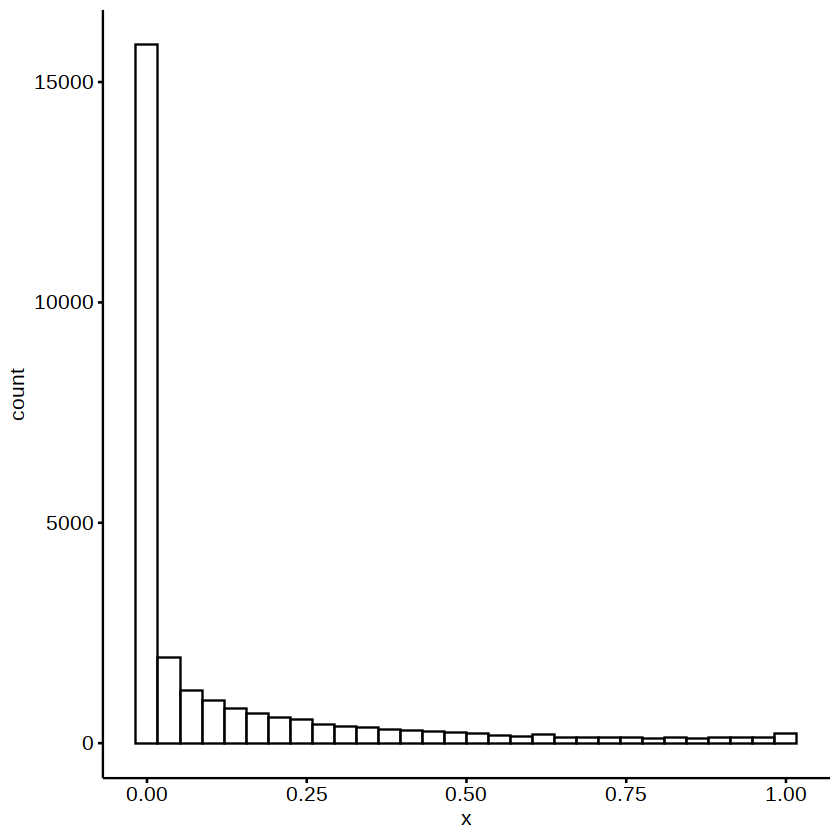

In [17]:
gghistogram(cdr)

In [18]:
# keeping genes present in 0.5% of total cells already reduces gene number to 11k
summary(cdr > 0.005)
genes_keep = names(cdr[cdr > 0.005])

orig_sce = orig_sce[genes_keep,]
ext_sce = ext_sce[genes_keep,]
tan_sce = tan_sce[genes_keep,]

   Mode   FALSE    TRUE 
logical   13833   13149 

#### Log normalisation per batch

In [19]:
# Normalisation, taking sample batches in to account for each dataset

assay = "cosineNorm"
# Multi batch normalisation on samples
orig_sce = multiBatchNorm(orig_sce, batch=as.factor(orig_sce$sample))
ext_sce = multiBatchNorm(ext_sce, batch=as.factor(ext_sce$sample))
tan_sce = multiBatchNorm(tan_sce, batch=as.factor(tan_sce$sample))

# Cosine normalisation
assay(orig_sce, assay) = cosineNorm(assay(orig_sce, "logcounts"))
assay(ext_sce, assay) = cosineNorm(assay(ext_sce, "logcounts"))
assay(tan_sce, assay) = cosineNorm(assay(tan_sce, "logcounts"))


In [21]:
# Remove differences in int_colData so that we can merge
orig_sce@int_colData@listData$size_factor = NULL
ext_sce@int_colData@listData$size_factor = NULL

# Concatenate
sce = cbind(orig_sce, ext_sce, tan_sce)

In [22]:
# Inspect sce's
orig_sce
ext_sce
tan_sce

class: SingleCellExperiment 
dim: 13149 13796 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(13149): Sox17 Mrpl15 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(13796): cell_363 cell_382 ... cell_139327 cell_139330
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 13149 50188 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(13149): Sox17 Mrpl15 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(50188): ext_cell_117 ext_cell_145 ... ext_cell_351871
  ext_cell_351872
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

class: SingleCellExperiment 
dim: 13149 44060 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(13149): Sox17 Mrpl15 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(44060): AAACCTGGTGCTCTTC-1-2 AAACCTGTCAACGAAA-1-2 ...
  TTTGTCAGTTAAGTAG-1-b TTTGTCATCGCCAGCA-1-b
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [23]:
# might need to remove logcounts from qiu and also everything else that's different

In [24]:
sce

class: SingleCellExperiment 
dim: 13149 108044 
metadata(0):
assays(3): counts logcounts cosineNorm
rownames(13149): Sox17 Mrpl15 ... mt-Nd6 mt-Cytb
rowData names(0):
colnames(108044): cell_363 cell_382 ... TTTGTCAGTTAAGTAG-1-b
  TTTGTCATCGCCAGCA-1-b
colData names(5): sample stage celltype dataset sizeFactor
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [25]:
saveRDS(sce, file.path(blood, 'sce.rds'))

In [64]:
table(viscello_meta$sample)


                 E10.5 AGM Endo E10.5 ATAC Paired Endothelium 2 
                           1733                            1635 
                E10.5 Cluster 3             E10.5 Cluster CD45+ 
                           1216                             394 
                   E10.5 Endo 1                    E10.5 Endo 2 
                            358                              85 
       E10.5 Entire Endothelium                      E10.5 HE 3 
                           3632                            1687 
                E10.5 Runx1 +/-               E10.5 Runx1 +/- 2 
                           1003                            3362 
                E10.5 Runx1 +/+               E10.5 Runx1 +/+ 2 
                            546                            2099 
E10.5 Umbilical & Viteline Endo                 E11.5 Cluster 1 
                            904                              17 
                E11.5 Cluster 2        E11.5 Cluster CD45+CD27+ 
                        

In [63]:
viscello_meta[sample=='E9.5 YS-EMP']

cell,sample,stage,celltype,dataset
<chr>,<chr>,<chr>,<chr>,<chr>
ACGCCAGAGTGTCTCA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
ACTTACTTCCACGTTC-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
AGAGCTTTCAATAAGG-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
AGCCTAAGTGCAGGTA-1-9,E9.5 YS-EMP,E9.5,HE,viscello
CAGCTGGAGGAATGGA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
CAGTAACCAGGACGTA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
CATCGAATCCGAGCCA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
CGATGGCGTTACGTCA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
CGCGTTTAGGACCACA-1-9,E9.5 YS-EMP,E9.5,IAC,viscello
